In [1]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [18]:
from pipeline.test import make_model

# 데이터 불러오기
df = pd.read_csv('./result/CD_VIF_col_5_with_segment.csv')

# C/D만 추출
df_cd = df[df['Segment'].isin(['C', 'D'])].copy()

# 라벨 인코딩 (C=0, D=1)
le = LabelEncoder()
df_cd['target'] = le.fit_transform(df_cd['Segment'])

# 입력/타겟 분리 (ID, Segment, target 제외)
X = df_cd.drop(columns=['ID', 'Segment', 'target']).values
y = df_cd['target'].values
feature_names = df_cd.drop(columns=['ID', 'Segment', 'target']).columns.tolist()

# 모델 학습
model, results = make_model(X, y, cv=10, file_name="Segment_cd")

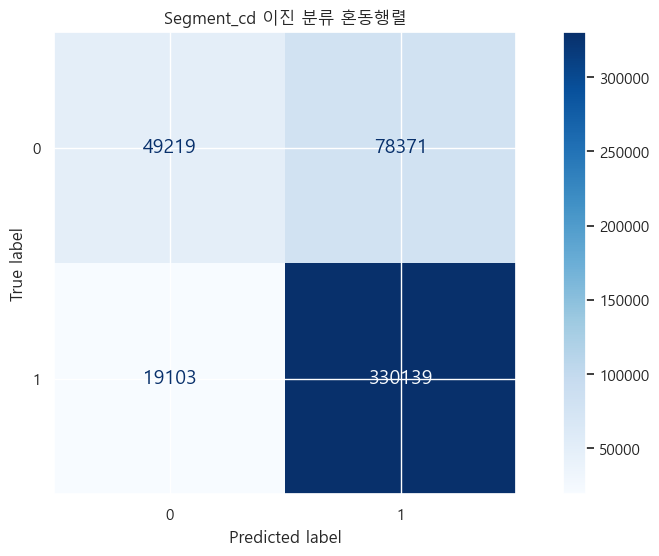

Classification Report
              precision    recall  f1-score   support

           0     0.7204    0.3858    0.5025    127590
           1     0.8082    0.9453    0.8714    349242

    accuracy                         0.7956    476832
   macro avg     0.7643    0.6655    0.6869    476832
weighted avg     0.7847    0.7956    0.7727    476832



In [20]:
# XGBoost Booster 로드
model = xgb.Booster()
model.load_model('./model/Segment_cd_Classifier_final.json')

# DMatrix 변환 및 예측
dtest = xgb.DMatrix(X)
y_prob = model.predict(dtest)
y_pred = (y_prob >= 0.5).astype(int)

# 혼동행렬
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Segment_cd 이진 분류 혼동행렬")
plt.show()

# 정밀도/재현율/F1 점수
print("Classification Report")
print(classification_report(y, y_pred, digits=4))

##### 결과
- D는 매우 잘 맞추지만, C는 거의 못 맞추고 있음
- C의 재현율이 0.39 : 실제 C 샘플 10개 중 6개 이상을 D로 예측
- 모델이 D로 쏠려 있음

| 클래스   | 샘플 수    |
| ----- | ------- |
| C (0) | 127,590 |
| D (1) | 349,242 |
- D 클래스가 2.7배 더 많음
- 선택한 피처가 C를 설명할 수 있는 정보가 부족한 듯함.

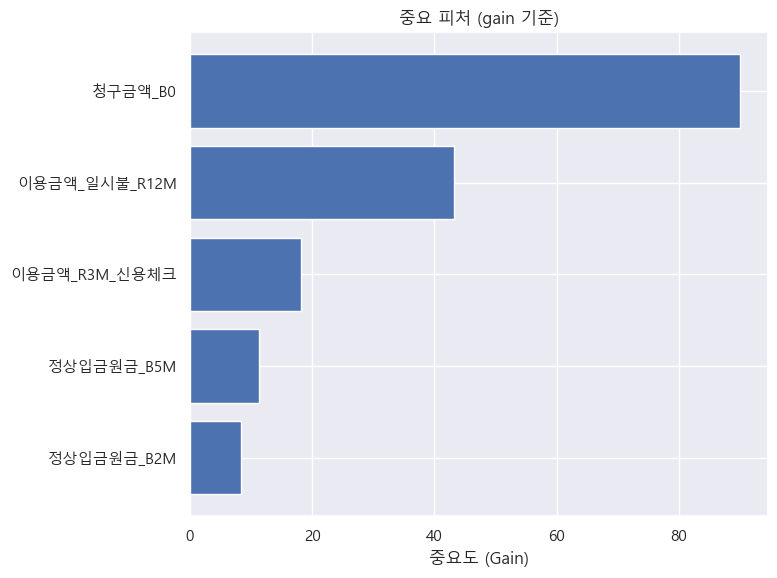

In [ ]:
# 중요도 딕셔너리 얻기
importance_dict = model.get_score(importance_type='gain')

# f0, f1, ... 을 실제 컬럼명으로 변환
feature_map = {f"f{i}": name for i, name in enumerate(feature_names)}
importance_named = {feature_map[k]: v for k, v in importance_dict.items()}

# 시각화
import matplotlib.pyplot as plt

sorted_items = sorted(importance_named.items(), key=lambda x: x[1], reverse=True)[:10]
names, scores = zip(*sorted_items)

plt.figure(figsize=(8, 6))
plt.barh(names[::-1], scores[::-1])  # 상위 피처부터 위로
plt.title("중요 피처 (gain 기준)")
plt.xlabel("중요도 (Gain)")
plt.tight_layout()
plt.show()